In [4]:
import pandas as pd
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [5]:
precision = 1e-10  # to avoid log(entropy==0) issues

In [8]:
output_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_OG'
chromosome = 'chr1'

crbarcode_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

In [9]:
import os 
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])

In [10]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [11]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [12]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000041
AAACAAGCAAACCTAG-1,207,17.0,8.212560,207,16.0,7.729469,0.000760
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN
AAACAAGCAAAGAAGC-1,987,46.0,4.660588,987,43.0,4.356636,0.003290


## Load CR's analysis on cell clustering 

In [13]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [14]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)

In [15]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,Cluster,log(total_fragments),log(entropy)
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN,6.020600e-01,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000041,NaN,4.342945e-11,-4.388199
AAACAAGCAAACCTAG-1,207,17.0,8.212560,207,16.0,7.729469,0.000760,NaN,2.315970e+00,-3.119059
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN,4.342945e-11,NaN
AAACAAGCAAAGAAGC-1,987,46.0,4.660588,987,43.0,4.356636,0.003290,NaN,2.994317e+00,-2.482768


In [16]:
all_df.dropna(inplace=False).shape

(1959, 10)

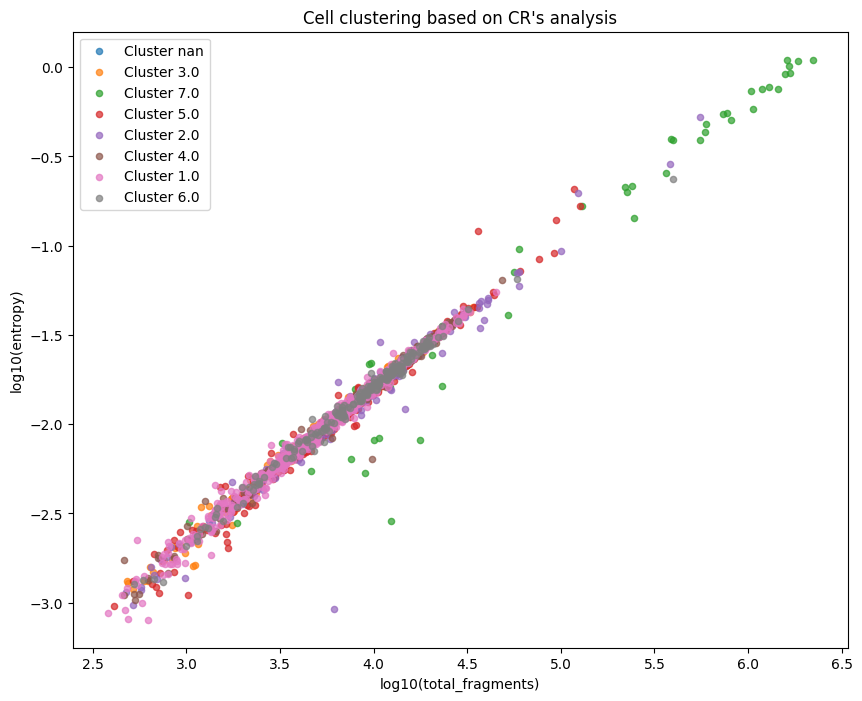

In [49]:
fig, ax = plt.subplots(figsize=(10,8))
for cluster in all_df['Cluster'].unique():
    cluster_data = all_df[all_df['Cluster'] == cluster]
    ax.scatter(cluster_data['log(total_fragments)'], cluster_data['log(entropy)'], label=f'Cluster {cluster}', s=20, alpha=0.7)

ax.set_xlabel('log10(total_fragments)')
ax.set_ylabel('log10(entropy)')
ax.set_title('Cell clustering based on CR\'s analysis')
ax.legend()


In [54]:
all_df.loc[~all_df['entropy'].isna(), ['frag_overlap_entropy_peaks%', 'frag_overlap_peaks%', 'entropy']].describe()

,frag_overlap_entropy_peaks%,frag_overlap_peaks%,entropy
count,87945.000000,87945.000000,87945.000000
mean,16.444259,15.877379,0.000873
std,26.748406,26.350996,0.012307
min,0.000000,0.000000,0.000021
25%,2.062430,1.791045,0.000041
50%,5.586592,5.263158,0.000113
75%,12.500000,11.788618,0.000420
max,100.000000,100.000000,1.102115


In [55]:
all_df.loc[~all_df['Cluster'].isna(), ['frag_overlap_entropy_peaks%', 'frag_overlap_peaks%', 'entropy']].describe()

,frag_overlap_entropy_peaks%,frag_overlap_peaks%,entropy
count,1959.000000,1959.000000,1959.000000
mean,66.862367,64.971816,0.023120
std,13.465931,13.328169,0.075192
min,1.648424,1.463187,0.000805
25%,64.079537,61.683067,0.007286
50%,69.519833,67.419389,0.013404
75%,74.257152,72.609101,0.021163
max,85.172704,83.866891,1.102115


# save barcodes corresponding to a particular cluster to a barcode file 
For double simulation

In [21]:

cluster_list = [1, 2]
for cluster in cluster_list:
    #cluster = 3
    cluster_barcodes = all_df[all_df['Cluster'] == cluster].index.tolist()
    cluster_barcodes

    barcodes_subdir = os.path.join(output_dir, 'cluster_barcodes')
    with open(os.path.join(barcodes_subdir, f'cluster_{cluster}_barcodes.txt'), 'w') as f:
        for bc in cluster_barcodes:
            f.write(f"{bc}\n")